<a href="https://colab.research.google.com/github/jayeshkoli-1402/ML-LAB/blob/main/Logistic_Reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/advertising.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1000, 10)


In [13]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')


In [14]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [15]:
print(df.isnull().sum())

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


In [16]:
df.describe(exclude=object)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [17]:
print(df["Clicked on Ad"].value_counts())

Clicked on Ad
0    500
1    500
Name: count, dtype: int64


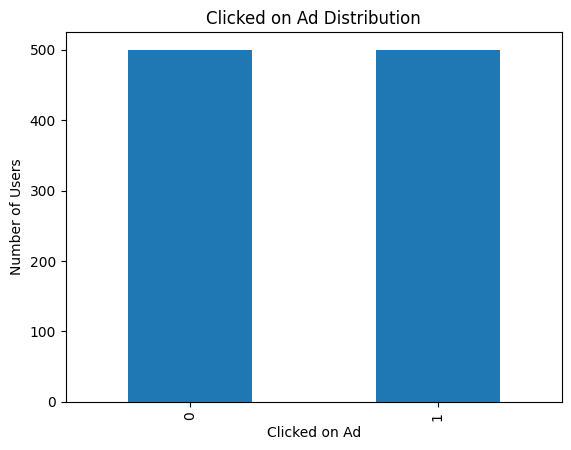

In [18]:
click_ad=df["Clicked on Ad"].value_counts()
click_ad.plot(kind="bar")

plt.title("Clicked on Ad Distribution")
plt.xlabel("Clicked on Ad")
plt.ylabel("Number of Users")
plt.show()

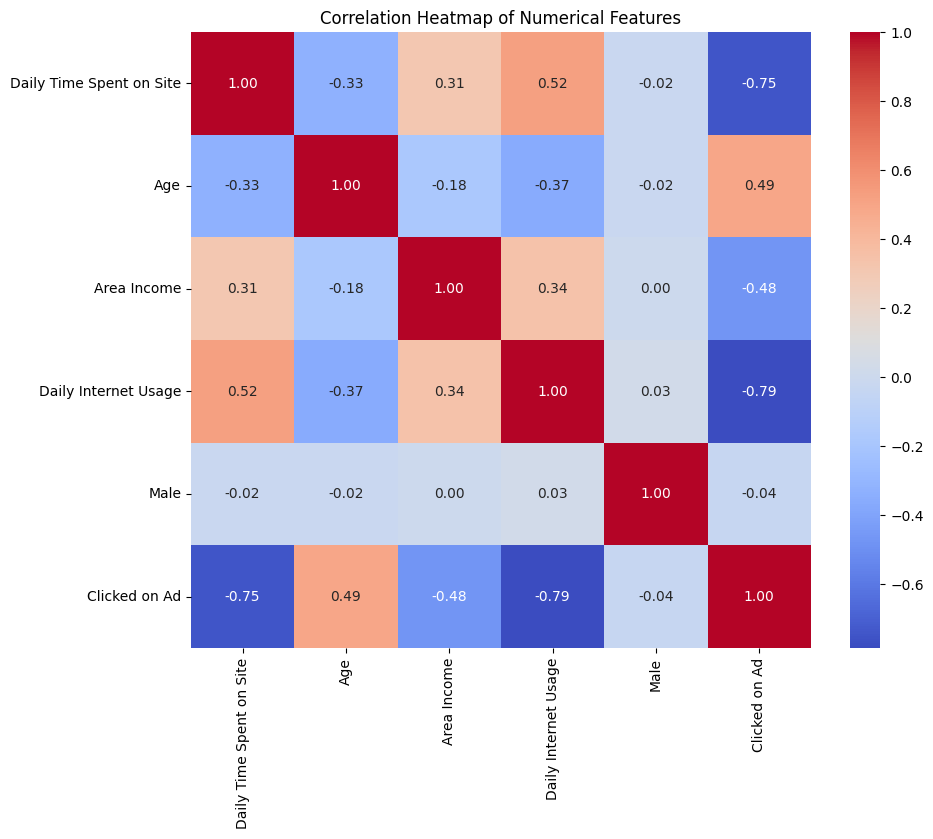

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True,
            cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [20]:
X = df[["Daily Time Spent on Site", "Daily Internet Usage"]]
y = df["Clicked on Ad"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Daily Time Spent on Site  Daily Internet Usage
0                     68.95                256.09
1                     80.23                193.77
2                     69.47                236.50
3                     74.15                245.89
4                     68.37                225.58

Target:
0    0
1    0
2    0
3    0
4    0
Name: Clicked on Ad, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.20, random_state=42, stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 2)
Testing data: (200, 2)


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [24]:
y_pred = model.predict(X_test_scaled)

y_probability = model.predict_proba(X_test_scaled)[:, 1]

print("Predicted classes:")
print(y_pred[:10])

print("\nPredicted probabilities:")
print(y_probability[:10])

Predicted classes:
[1 0 0 0 1 1 1 1 0 0]

Predicted probabilities:
[0.99878923 0.0189869  0.00817417 0.07414317 0.98485865 0.99751288
 0.94456674 0.94819075 0.16328692 0.02313479]


In [25]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.96


In [26]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[96  4]
 [ 4 96]]


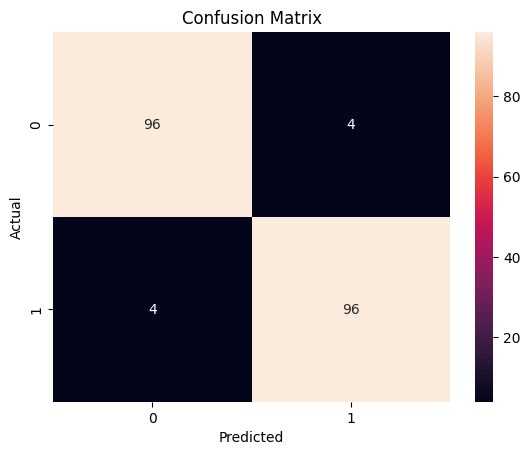

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       100
           1       0.96      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [29]:
from sklearn.metrics import precision_score
print('Precision')

Precision


AUC: 0.9869


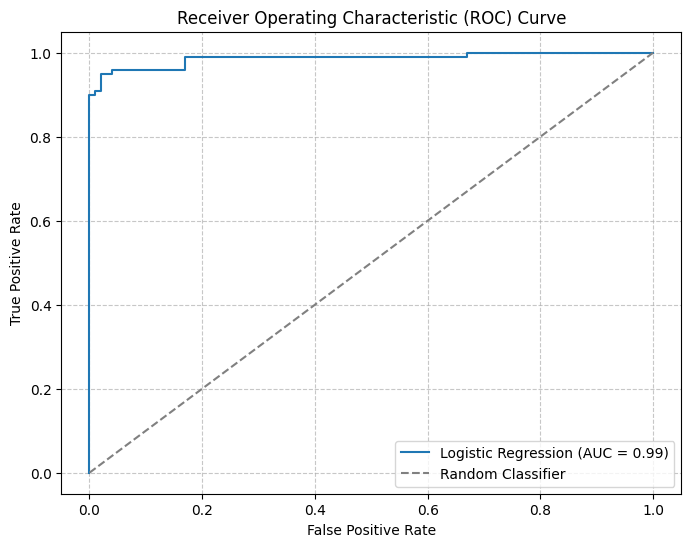

In [30]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

auc = roc_auc_score(y_test, y_probability)

print("AUC:", auc)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color='gray', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

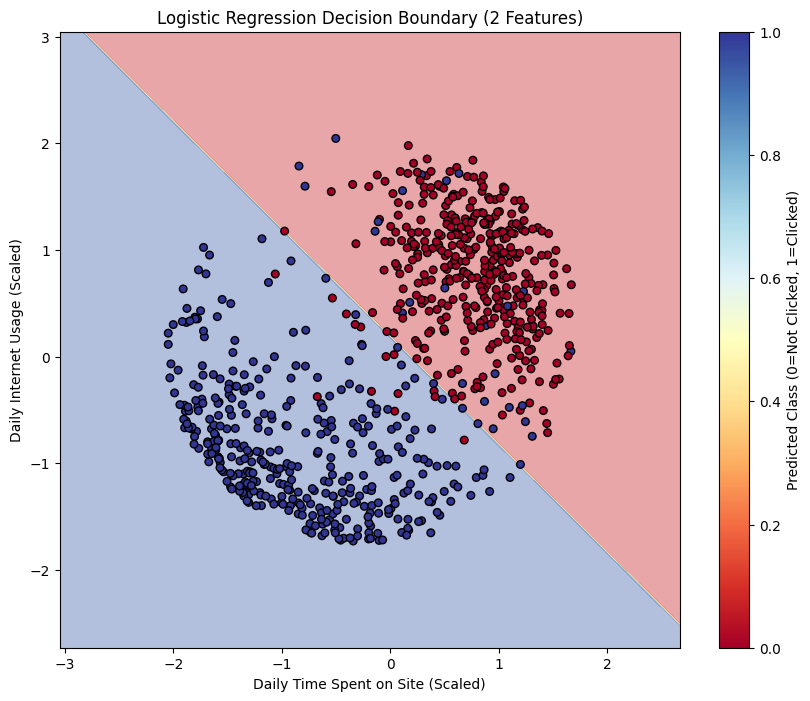

In [31]:
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)

plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
    c=y_train, s=30, edgecolor='k', cmap=plt.cm.RdYlBu)

plt.xlabel("Daily Time Spent on Site (Scaled)")
plt.ylabel("Daily Internet Usage (Scaled)")
plt.title("Logistic Regression Decision Boundary (2 Features)")
plt.colorbar(label='Predicted Class (0=Not Clicked, 1=Clicked)')
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

logits = X_test_scaled @ model.coef_.T + model.intercept_

sorted_indices = np.argsort(logits.flatten())
sorted_logits = logits.flatten()[sorted_indices]
sorted_probabilities = y_probability[sorted_indices]

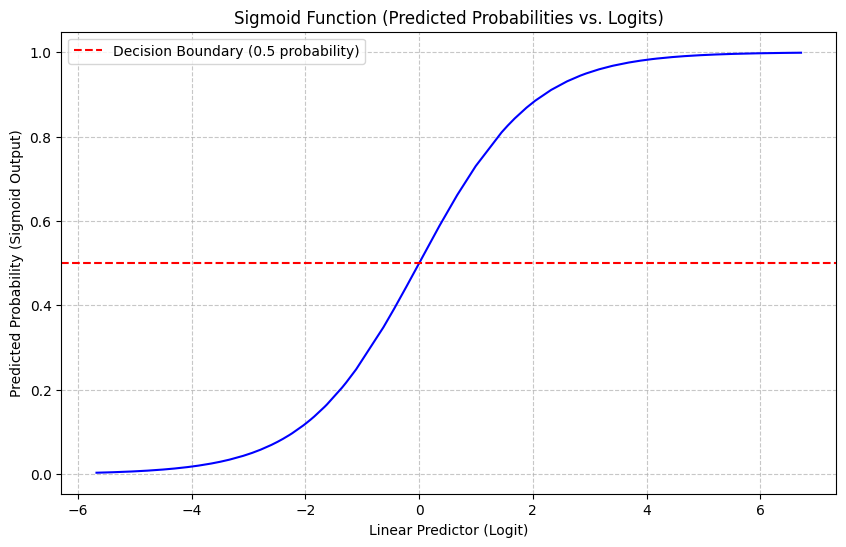

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(sorted_logits, sorted_probabilities, color='blue')

plt.xlabel("Linear Predictor (Logit)")
plt.ylabel("Predicted Probability (Sigmoid Output)")
plt.title("Sigmoid Function (Predicted Probabilities vs. Logits)")
plt.grid(True, linestyle='--', alpha=0.7)

plt.axhline(0.5, color='red', linestyle='--',
            label='Decision Boundary (0.5 probability)')
plt.legend()
plt.show()